In [57]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
# 1. FLIPKART URL
url = "https://www.flipkart.com/search?q=shoes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off"
# 2. HEADERS
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/150.0.0.0 Safari/537.36"
}
# 3. EMPTY LIST
all_shoes = []
# 4. GENDER FUNCTION

def get_gender(text):

    text = text.lower()

    if re.search(r"\bmen\b|\bmen's\b|\bmale\b", text):
        return "Men"

    elif re.search(r"\bwomen\b|\bwomen's\b|\bfemale\b|\bladies\b", text):
        return "Women"

    elif re.search(r"\bboys\b|\bboy\b", text):
        return "Boys"

    elif re.search(r"\bgirls\b|\bgirl\b", text):
        return "Girls"

    elif "unisex" in text:
        return "Unisex"

    else:
        return "Unknown"
# 5. SCRAPE 13 PAGES
for page in range(1, 14):

    print("=" * 60)
    print("Scraping page:", page)

    page_url = url + f"&page={page}"

    response = requests.get(
        page_url,
        headers=headers
    )

    print("Status code:", response.status_code)

    # 6. BEAUTIFULSOUP
    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )
    # 7. PRODUCT CONTAINERS
    products = soup.find_all(
        "div",
        class_="bLCLBY nr15la"
    )

    print("Products found:", len(products))
    # 8. EXTRACT EACH PRODUCT

    for product in products:


        
        # PRODUCT ID
        

        product_id = product.get("data-id")


        # BRAND
    

        brand_tag = product.find(
            "div",
            class_="Fo1I0b"
        )

        brand = (
            brand_tag.get_text(strip=True)
            if brand_tag
            else None
        )
        # PRODUCT NAME

        product_tag = product.find(
            "a",
            class_="atJtCj"
        )

        product_name = (
            product_tag.get_text(strip=True)
            if product_tag
            else None
        )

        # GENDER
        

        product_text = product.get_text(
            " ",
            strip=True
        )

        gender = get_gender(
            product_text
        )


        
        # PRICE

        price_tag = product.find(
            "div",
            class_="hZ3P6w"
        )

        price = (
            price_tag.get_text(strip=True)
            if price_tag
            else None
        )



        # ORIGINAL PRICE


        original_price_tag = product.find(
            "div",
            class_="kRYCnD"
        )

        original_price = (
            original_price_tag.get_text(strip=True)
            if original_price_tag
            else None
        )


        
        # DISCOUNT
        

        discount_tag = product.find(
            "div",
            class_="HQe8jr"
        )

        discount = (
            discount_tag.get_text(strip=True)
            if discount_tag
            else None
        )

        # STORE DATA

        all_shoes.append({

            "Product ID": product_id,
            "Brand": brand,
            "Product": product_name,
            "Gender": gender,
            "Price": price,
            "Original Price": original_price,
            "Discount": discount

        })


        # STOP AT 500

        if len(all_shoes) >= 500:
            break

    # STOP PAGINATION

    if len(all_shoes) >= 500:
        break


    # Wait before next request
    time.sleep(2)

# 9. CREATE DATAFRAME

df = pd.DataFrame(
    all_shoes[:500]
)


# 10. DISPLAY TOTAL

print("\n" + "=" * 60)

print(
    "Total products:",
    len(df)
)

# 11. DISPLAY COLUMNS

print("\nColumns:")

print(
    df.columns.tolist()
)

# 12. DISPLAY FIRST 10 ROWS

print("\nFirst 10 products:")

print(
    df.head(10)
)

# 13. CHECK MISSING VALUES


print("\nMissing values:")

print(
    df.isnull().sum()
)


# 14. SAVE CSV

df.to_csv(
    "flipkart_500_shoes.csv",
    index=False
)

print("\nCSV saved successfully!")

Scraping page: 1
Status code: 200
Products found: 40
Scraping page: 2
Status code: 200
Products found: 40
Scraping page: 3
Status code: 200
Products found: 40
Scraping page: 4
Status code: 200
Products found: 40
Scraping page: 5
Status code: 200
Products found: 40
Scraping page: 6
Status code: 200
Products found: 40
Scraping page: 7
Status code: 200
Products found: 40
Scraping page: 8
Status code: 200
Products found: 40
Scraping page: 9
Status code: 200
Products found: 40
Scraping page: 10
Status code: 200
Products found: 40
Scraping page: 11
Status code: 200
Products found: 40
Scraping page: 12
Status code: 200
Products found: 40
Scraping page: 13
Status code: 200
Products found: 40

Total products: 500

Columns:
['Product ID', 'Brand', 'Product', 'Gender', 'Price', 'Original Price', 'Discount']

First 10 products:
  Product ID          Brand  \
0       None       HOTSTYLE   
1       None  WHITE WALKERS   
2       None          NIVIA   
3       None          Echor   
4       None     

In [2]:
import pandas as pd
df = pd.read_csv(
    "flipkart_500_shoes.csv")
df

,Product ID,Brand,Product,Gender,Price,Original Price,Discount
0,NaN,HOTSTYLE,Trendy & Stylish Running Shoes For Men,Men,₹229,₹999,77% off
1,NaN,WHITE WALKERS,Sneakers For Men,Men,₹438,"₹1,999",78% off
2,NaN,NIVIA,AIR STRIKE Football Shoes For Men,Men,₹431,"₹1,069",59% off
3,NaN,Echor,ESGRPEP Sneakers For Men,Men,₹370,"₹1,999",81% off
4,NaN,Free Kicks,FK-Run Premium Running Shoes For Men,Men,₹186,₹699,73% off
...,...,...,...,...,...,...,...
495,NaN,RED TAPE,Athleisure Shoes for Women | Cultured Round-To...,Women,"₹1,231","₹8,799",86% off
496,NaN,WHITE WALKERS,Sneakers For Men,Men,₹438,"₹1,999",78% off
497,NaN,STRANGER BROTHERS,Sneakers For Men | Casual Shoes For Men | Whit...,Men,₹391,₹999,60% off
498,NaN,CAMPUS,SWOON Running Shoes For Men,Men,"₹1,110","₹2,999",62% off


### Remove unnecessary columns/rows

In [3]:
df = df.drop("Product ID", axis=1)

### checking column datatypes 

In [4]:
df.dtypes

Brand             object
Product           object
Gender            object
Price             object
Original Price    object
Discount          object
dtype: object

### changing wrong datatypes to correct datatypes

In [5]:
# convert price column from string to int 
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
# convert Original Price column from string to int 
df["Original Price"] = (
    df["Original Price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Original Price"] = pd.to_numeric(df["Original Price"], errors="coerce")

In [6]:
df.head()

,Brand,Product,Gender,Price,Original Price,Discount
0,HOTSTYLE,Trendy & Stylish Running Shoes For Men,Men,229,999.0,77% off
1,WHITE WALKERS,Sneakers For Men,Men,438,1999.0,78% off
2,NIVIA,AIR STRIKE Football Shoes For Men,Men,431,1069.0,59% off
3,Echor,ESGRPEP Sneakers For Men,Men,370,1999.0,81% off
4,Free Kicks,FK-Run Premium Running Shoes For Men,Men,186,699.0,73% off


### checking null values in the whole data frame

In [7]:
df[df.isnull().values]

,Brand,Product,Gender,Price,Original Price,Discount
213,PUMA,Rungryp Sneakers For Men,Men,4999,NaN,NaN
213,PUMA,Rungryp Sneakers For Men,Men,4999,NaN,NaN


In [8]:
# checking the null value percentage of the in the dataframe
null_percentage = df.isnull().sum().sum() / df.size * 100

print(null_percentage)

0.06666666666666667


### deleting the null value rows

In [9]:
df = df.drop(213)

### checking the duplicates present or not 

In [10]:
df.duplicated().any()

np.True_

### deleting the duplicated rows from the dataframe

In [11]:
df = df.drop_duplicates()

In [12]:
# rechecking the duplicated values present or not
df.duplicated().any()

np.False_

In [13]:
df

,Brand,Product,Gender,Price,Original Price,Discount
0,HOTSTYLE,Trendy & Stylish Running Shoes For Men,Men,229,999.0,77% off
1,WHITE WALKERS,Sneakers For Men,Men,438,1999.0,78% off
2,NIVIA,AIR STRIKE Football Shoes For Men,Men,431,1069.0,59% off
3,Echor,ESGRPEP Sneakers For Men,Men,370,1999.0,81% off
4,Free Kicks,FK-Run Premium Running Shoes For Men,Men,186,699.0,73% off
...,...,...,...,...,...,...
492,asian,"Moscow-01 White Sneakers,Loafers,Chunky Shoes ...",Unknown,793,1499.0,47% off
493,Echor,Black Sneakers Shoes for Men Sneakers For Men,Men,418,1999.0,79% off
495,RED TAPE,Athleisure Shoes for Women | Cultured Round-To...,Women,1231,8799.0,86% off
498,CAMPUS,SWOON Running Shoes For Men,Men,1110,2999.0,62% off


### checking the outlier present or not

In [14]:
# for outliers detection and removing the outliers
class OutlierRemover: 
    def __init__(self, df):
        self.df = df.copy() 

    def read_outliers(self, col):
        q1 = self.df[col].quantile(0.25)
        q3 = self.df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = self.df[
            (self.df[col] < lower_bound) |
            (self.df[col] > upper_bound)
        ]
        return outliers

    def update_outlier_iqr(self, col):
        q1 = self.df[col].quantile(0.25)
        q3 = self.df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Filter self.df in-place
        self.df = self.df[
            (self.df[col] >= lower_bound) &
            (self.df[col] <= upper_bound)
        ]
        return self.df

    def update_outliers_capping(self, col):
        q1 = self.df[col].quantile(0.25)
        q3 = self.df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        self.df[col] = self.df[col].clip(lower=lower_bound, upper=upper_bound)
        return self.df

outlier_detector = OutlierRemover(df)

outlier_detector.update_outlier_iqr("Price")
cleaned_df = outlier_detector.update_outlier_iqr("Original Price")
print(cleaned_df)

             Brand                                            Product  \
0         HOTSTYLE             Trendy & Stylish Running Shoes For Men   
1    WHITE WALKERS                                   Sneakers For Men   
2            NIVIA                  AIR STRIKE Football Shoes For Men   
3            Echor                           ESGRPEP Sneakers For Men   
4       Free Kicks               FK-Run Premium Running Shoes For Men   
..             ...                                                ...   
489           aadi  Men's Comfortable Lightweight Outdoor Lace Up ...   
492          asian  Moscow-01 White Sneakers,Loafers,Chunky Shoes ...   
493          Echor      Black Sneakers Shoes for Men Sneakers For Men   
498         CAMPUS                        SWOON Running Shoes For Men   
499          Abros                    AVALON-ON Running Shoes For Men   

      Gender  Price  Original Price Discount  
0        Men    229           999.0  77% off  
1        Men    438          

In [15]:
df = pd.DataFrame(cleaned_df)

In [16]:
df

,Brand,Product,Gender,Price,Original Price,Discount
0,HOTSTYLE,Trendy & Stylish Running Shoes For Men,Men,229,999.0,77% off
1,WHITE WALKERS,Sneakers For Men,Men,438,1999.0,78% off
2,NIVIA,AIR STRIKE Football Shoes For Men,Men,431,1069.0,59% off
3,Echor,ESGRPEP Sneakers For Men,Men,370,1999.0,81% off
4,Free Kicks,FK-Run Premium Running Shoes For Men,Men,186,699.0,73% off
...,...,...,...,...,...,...
489,aadi,Men's Comfortable Lightweight Outdoor Lace Up ...,Men,430,1999.0,78% off
492,asian,"Moscow-01 White Sneakers,Loafers,Chunky Shoes ...",Unknown,793,1499.0,47% off
493,Echor,Black Sneakers Shoes for Men Sneakers For Men,Men,418,1999.0,79% off
498,CAMPUS,SWOON Running Shoes For Men,Men,1110,2999.0,62% off


In [17]:
# removing unknown values to some value 
df["Gender"] = df["Gender"].replace("Unknown", "men and women")

### Adding size column

In [18]:
import numpy as np
df["size"] = np.where(df["Price"] < 500, 8, 10)

In [19]:
df

,Brand,Product,Gender,Price,Original Price,Discount,size
0,HOTSTYLE,Trendy & Stylish Running Shoes For Men,Men,229,999.0,77% off,8
1,WHITE WALKERS,Sneakers For Men,Men,438,1999.0,78% off,8
2,NIVIA,AIR STRIKE Football Shoes For Men,Men,431,1069.0,59% off,8
3,Echor,ESGRPEP Sneakers For Men,Men,370,1999.0,81% off,8
4,Free Kicks,FK-Run Premium Running Shoes For Men,Men,186,699.0,73% off,8
...,...,...,...,...,...,...,...
489,aadi,Men's Comfortable Lightweight Outdoor Lace Up ...,Men,430,1999.0,78% off,8
492,asian,"Moscow-01 White Sneakers,Loafers,Chunky Shoes ...",men and women,793,1499.0,47% off,10
493,Echor,Black Sneakers Shoes for Men Sneakers For Men,Men,418,1999.0,79% off,8
498,CAMPUS,SWOON Running Shoes For Men,Men,1110,2999.0,62% off,10


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           274 non-null    object 
 1   Product         274 non-null    object 
 2   Gender          274 non-null    object 
 3   Price           274 non-null    int64  
 4   Original Price  274 non-null    float64
 5   Discount        274 non-null    object 
 6   size            274 non-null    int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 17.1+ KB


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the cleaned dataset
df = pd.read_csv("cleaned_flipkart_500_shoes.csv")

# Display first 5 rows
df.head()

,Brand,Product,Gender,Price,Original Price,Discount,size
0,HOTSTYLE,Trendy & Stylish Running Shoes For Men,Men,229,999.0,77% off,8
1,WHITE WALKERS,Sneakers For Men,Men,438,1999.0,78% off,8
2,NIVIA,AIR STRIKE Football Shoes For Men,Men,431,1069.0,59% off,8
3,Echor,ESGRPEP Sneakers For Men,Men,370,1999.0,81% off,8
4,Free Kicks,FK-Run Premium Running Shoes For Men,Men,186,699.0,73% off,8


In [27]:
df.columns

Index(['Brand', 'Product', 'Gender', 'Price', 'Original Price', 'Discount',
       'size'],
      dtype='object')

# Problem Statement
  - "Analyzing Pricing Strategies and Discounts of Shoes on Flipkart"

# Objective:

To analyze how brand, gender, and shoe size influence the selling price, original price, and discount percentage of shoes listed on Flipkart. The goal is to identify pricing patterns, discount strategies, and relationships among different product features.

- Target Variable
- Price
- Predictor Variables
- Brand
- Gender
- Original Price
- Discount
- size
# Business Questions
- Which brands have the highest average selling price?
- Which brands offer the highest discounts?
- Is there a relationship between Original Price and Selling Price?
- Do men's and women's shoes have different average prices?
- Does shoe size affect the selling price?
- Which brands provide the best value after discount?

# 1. Univariate Analysis

# Histogram of Price

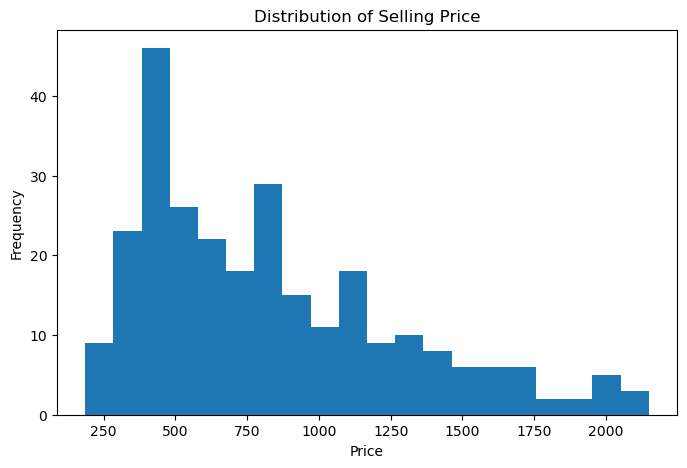

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=20)
plt.title("Distribution of Selling Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Observation
- Most shoes are priced between ₹300 and ₹1000.
- The highest concentration is around ₹400–₹600.
- Very few shoes cost above ₹1800.
# Interpretation

- The histogram is positively (right) skewed because there are many low-priced shoes and only a few expensive shoes.

# Relation to Problem Statement

This indicates that Flipkart mainly targets budget-conscious customers, while only a small portion of products belong to the premium segment.

# Histogram of Discount


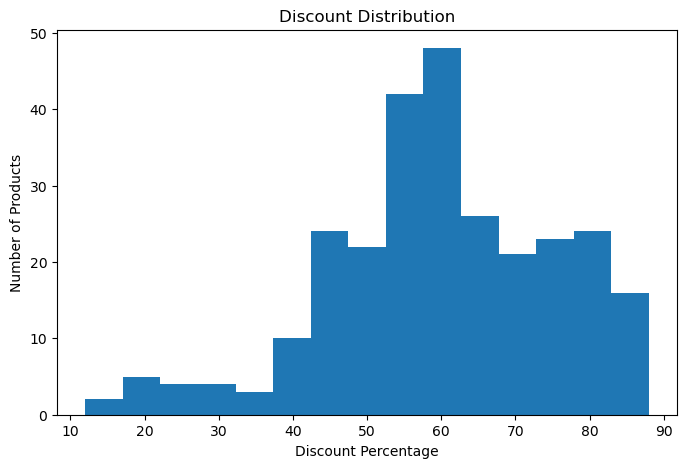

In [39]:
plt.figure(figsize=(8,5))
plt.hist(df['Discount'].dropna(),bins=15)
plt.title('Discount Distribution')
plt.xlabel('Discount Percentage')
plt.ylabel('Number of Products')
plt.show()

# Observation
- Discounts vary widely across products.
- Most products receive medium to high discounts.
- The x-axis labels overlap because the Discount column is probably stored as strings instead of numeric values.
# Interpretation

- This graph helps understand discount strategies offered on shoes.

# Relation to Problem Statement

- This graph shows that discount is one of the major pricing strategies used by sellers.

# Bar Chart of Brand Counts

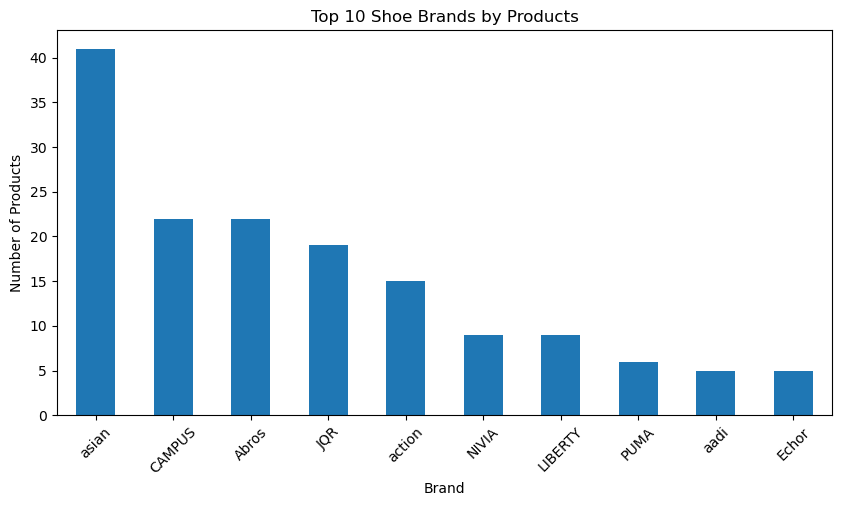

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
df['Brand'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Shoe Brands by Products')
plt.xlabel('Brand')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.show()

# Observation
- Only a few brands (such as Campus, Asian, etc.) have many products.
- Most brands have only 1–5 products.
# Interpretation

- The dataset is dominated by a few brands, while many brands have limited representation.
- This graph shows product availability by brand. Brands with higher counts have more products in the collected dataset.

# Relation to Problem Statement

- Brands with more products are likely to follow different pricing and discount strategies compared with brands that have only a few listings.

# Pie Chart of Gender

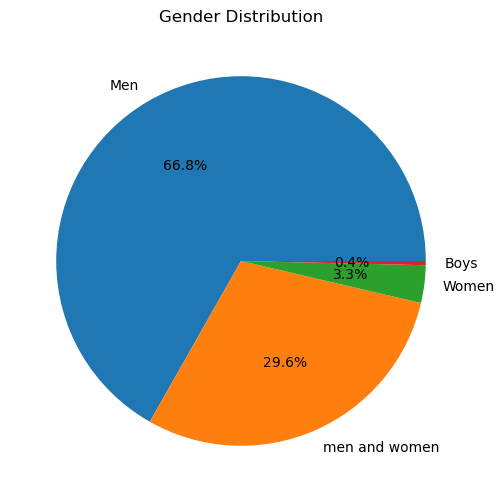

In [9]:
gender = df["Gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender,
        labels=gender.index,
        autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()

# Observation
- Men: 66.8%
- Men & Women (Unisex): 29.6%
- Women: 3.3%
- Boys: 0.4%
# Interpretation

- The dataset is heavily dominated by men's footwear.

# Relation to Problem Statement

The pricing analysis will mainly reflect the men's shoe market.

# 2. Bivariate Analysis
# Average Price by Brand

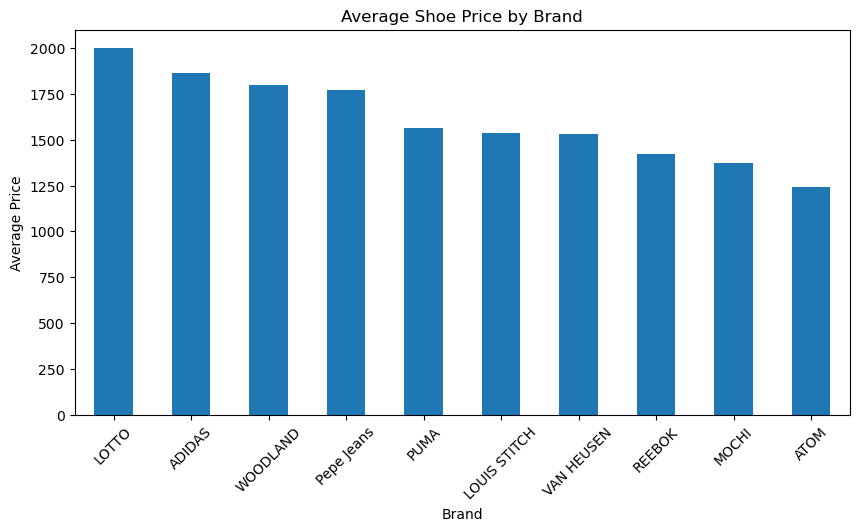

In [43]:
avg=df.groupby('Brand')['Price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
avg.plot(kind='bar')
plt.title('Average Shoe Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

# Observation
- Some brands have an average price close to ₹2000.
- Many brands have average prices between ₹300–₹900.
# Interpretation

- Different brands target different customer segments.

- Premium brands charge more than budget brands.

# Relation to Problem Statement

This directly supports the objective of analyzing how brand influences selling price.

# Average Discount by Brand

In [12]:
print(df["Discount"].dtype)
print(df["Discount"].head())

object
0    77% off
1    78% off
2    59% off
3    81% off
4    73% off
Name: Discount, dtype: object


In [32]:
# changing datatype of discount
df["Discount"] = (
    df["Discount"]
    .str.replace("% off", "", regex=False)
    .astype(int)
)

In [ ]:
df["Discount"] = (
    df["Discount"]
    .str.replace("% off", "", regex=False)
    .str.strip()
)

df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce")

In [34]:
print(df["Discount"].dtype)

int64


In [35]:
print(df["Discount"].head(10))

0    77
1    78
2    59
3    81
4    73
5    70
6    78
7    66
8    79
9    81
Name: Discount, dtype: int64


In [36]:
print(df["Discount"].apply(type).value_counts())

Discount
<class 'int'>    274
Name: count, dtype: int64


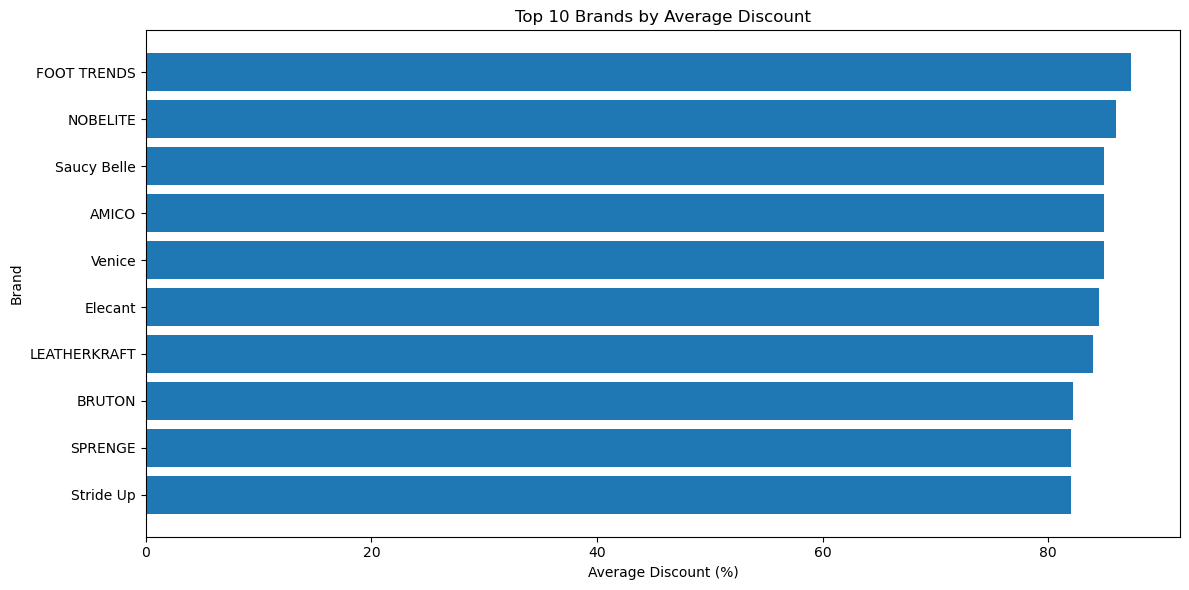

In [46]:
brand_discount = (
    df.groupby("Brand")["Discount"]
      .mean()
      .sort_values()
      .tail(10)
)

plt.figure(figsize=(12,6))
plt.barh(brand_discount.index, brand_discount.values)

plt.title("Top 10 Brands by Average Discount")
plt.xlabel("Average Discount (%)")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

# Observation
- Average discounts range from approximately 20% to nearly 90%.
- Some brands consistently offer very high discounts.
# Interpretation

- Brands use different promotional strategies.

- High-discount brands may be trying to attract more customers or clear inventory.

# Relation to Problem Statement

This explains how different brands use discounts as part of their pricing strategy.

# Scatter Plot

# Original Price vs Selling Price

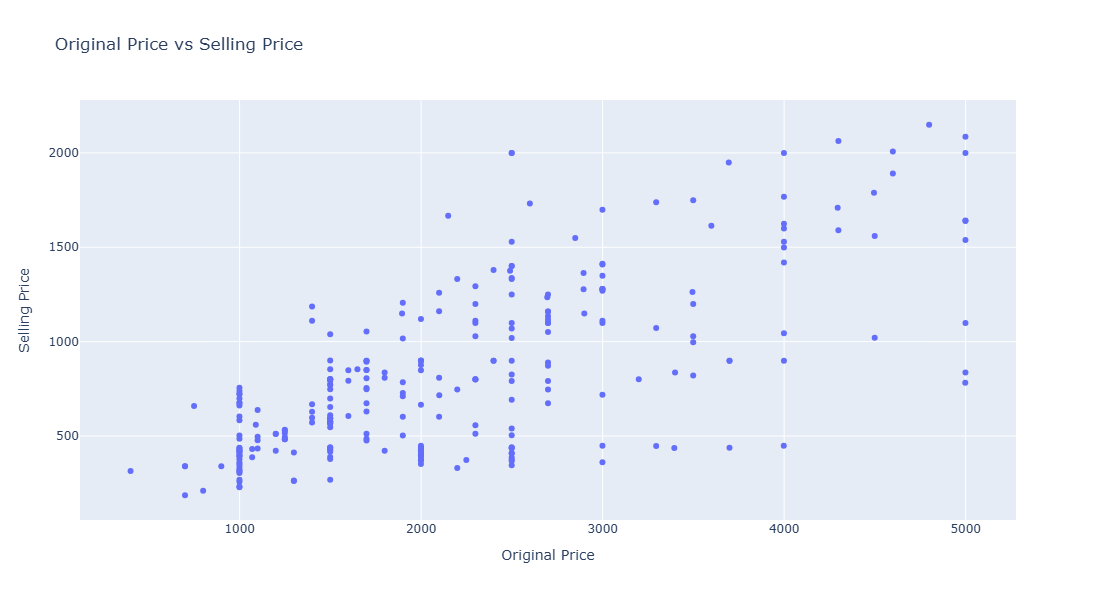

In [47]:
import plotly.express as px

fig = px.scatter(
    df,
    x="Original Price",
    y="Price",
    title="Original Price vs Selling Price",
    labels={
        "Original Price": "Original Price",
        "Price": "Selling Price"
    }
)

fig.update_layout(
    width=800,
    height=600
)

fig.show()

# Graph Output

-The scatter plot shows points distributed diagonally from lower-left to upper-right.

- Shoes with low original prices have lower selling prices.
- Shoes with high original prices have higher selling prices.
- The points are not perfectly aligned because discounts create variations.
# Interpretation

- There is a positive relationship between Original Price and Selling Price.

- When the original price increases, the selling price generally increases.

- However, some products with high original prices have lower selling prices due to higher discounts.

# Relation to Problem Statement

- This graph proves that Original Price is one of the major factors affecting Selling Price.

- Sellers first decide the product value and then apply discounts to determine the final selling price.

# Business Insight

Premium shoes maintain higher selling prices even after discounts.

# Average Price by Gender

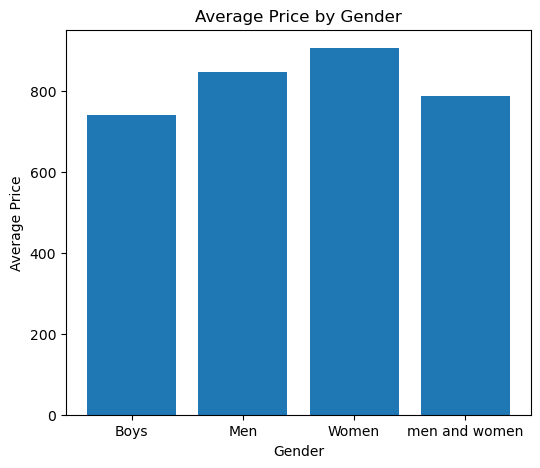

In [21]:
gender_price = df.groupby("Gender")["Price"].mean()

plt.figure(figsize=(6,5))

plt.bar(gender_price.index,
        gender_price.values)

plt.title("Average Price by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Price")

plt.show()

# Graph Output

- The graph compares average shoe prices among different gender categories:

- Boys
- Men
- Women
- Men and Women (Unisex)

# From the graph:

- Women's shoes have the highest average price.
- Men's shoes also have a higher average price.
- Boys' shoes have the lowest average price.
# Interpretation

- Different customer segments have different pricing levels.

- Women's and men's footwear are positioned in higher price categories compared with children's footwear.

# Relation to Problem Statement

- Gender influences the pricing pattern because different customer groups have different product positioning and demand.

# Business Insight

- Sellers use gender-based segmentation while deciding prices.

# Size vs Price

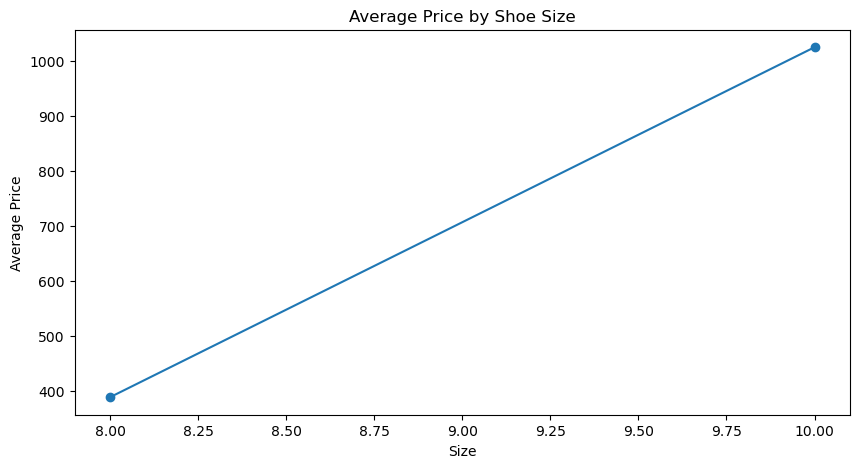

In [24]:
size_price = df.groupby("size")["Price"].mean()

plt.figure(figsize=(10,5))

plt.plot(size_price.index,
         size_price.values,
         marker="o")

plt.title("Average Price by Shoe Size")
plt.xlabel("Size")
plt.ylabel("Average Price")

plt.show()

# Graph Output

- The graph shows:

- Size 8:

- Average price around ₹400

- Size 10:

- Average price around ₹1000
# Interpretation

- The average price increases with shoe size.

- However, this relationship may not be completely reliable because size 10 may have fewer products.

# Relation to Problem Statement

- Shoe size has some influence on price, but it is not as important as:

- Brand
- Original Price
- Discount
# Business Insight

Size availability affects product distribution more than pricing strategy.

# 3. Multivariate Analysis
# Brand vs Gender vs Average Price

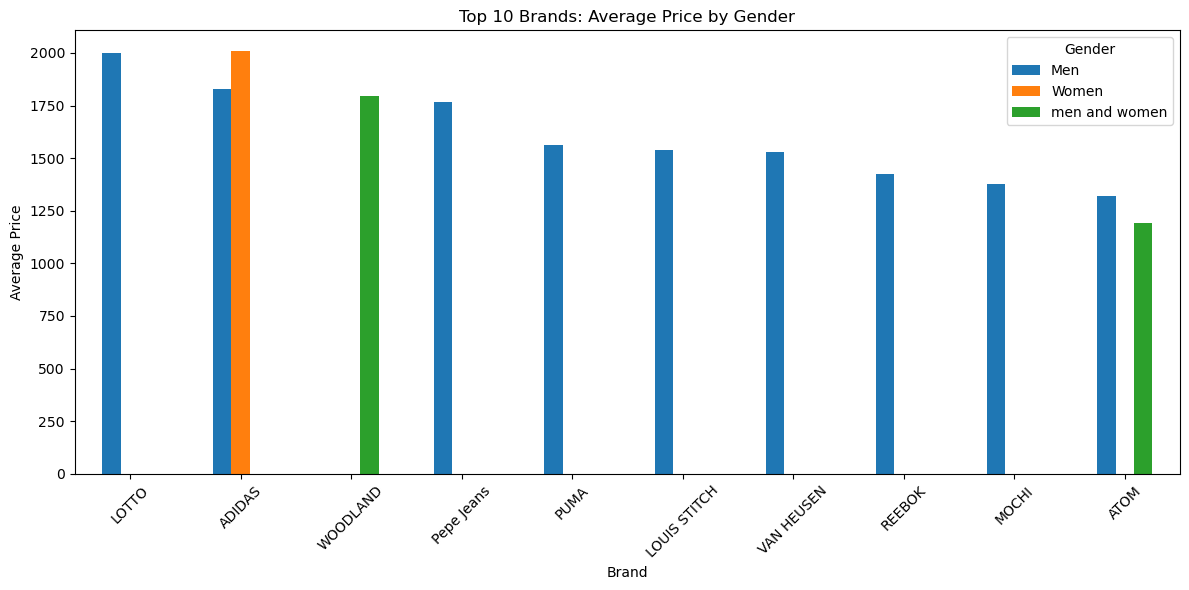

In [53]:
# Top 10 brands by average price
top_brands = (
    df.groupby("Brand")["Price"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .index
)

# Filter data
df_top = df[df["Brand"].isin(top_brands)]

# Create pivot table
pivot = df_top.pivot_table(
    values="Price",
    index="Brand",
    columns="Gender",
    aggfunc="mean"
)

# Sort brands by overall average price
pivot = pivot.loc[
    df_top.groupby("Brand")["Price"]
          .mean()
          .sort_values(ascending=False)
          .index
]

# Plot
pivot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top 10 Brands: Average Price by Gender")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Graph Output

- The graph compares average prices of different brands across gender categories.

# Observations:

- Some brands have higher prices for men's footwear.
- Some brands have higher prices for women's footwear.
- Many brands have limited gender categories available.
# Interpretation

- Pricing differs not only by brand but also by the target customer segment.

- A premium brand may maintain higher prices across all gender categories.

# Relation to Problem Statement

- This graph explains the combined effect of:

- Brand + Gender → Selling Price

- It helps identify whether brands follow different pricing strategies for different customers.

# Problem with Graph

- There are too many brands, making visualization difficult.

# Brand vs Discount vs Original Price

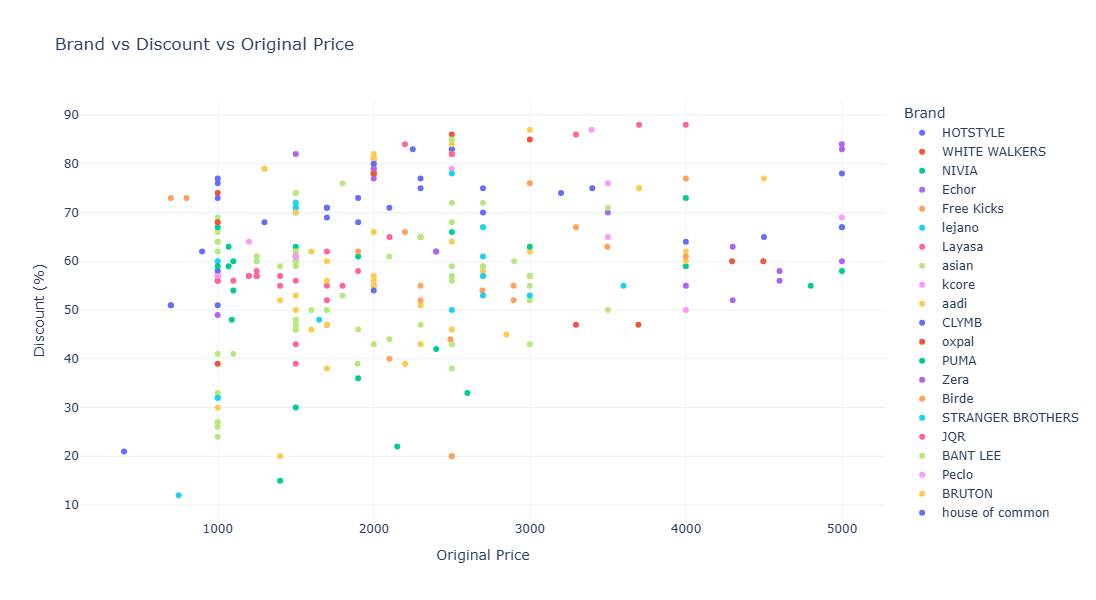

In [50]:
import plotly.express as px

fig = px.scatter(
    df,
    x="Original Price",
    y="Discount",
    color="Brand",
    hover_data=["Brand", "Price"],
    title="Brand vs Discount vs Original Price",
    labels={
        "Original Price": "Original Price",
        "Discount": "Discount (%)"
    }
)

fig.update_layout(
    width=1000,
    height=600,
    template="plotly_white"
)

fig.show()

# Graph Output

- The graph shows:

- X-axis → Discount percentage
- Y-axis → Original Price

- Most points are spread between:

- 40%–80% discount
- ₹1000–₹5000 original price
# Interpretation

- Higher-priced shoes also receive discounts.

- There is no strong direct relationship between original price and discount percentage.

- Some expensive shoes receive large discounts, while some cheaper shoes receive smaller discounts.

# Relation to Problem Statement

- This shows that sellers use discounts as an independent pricing strategy.

- Discount percentage depends on marketing decisions rather than only product price.

# Business Insight

Large discounts can be used to attract customers and increase sales.

# Correlation Analysis

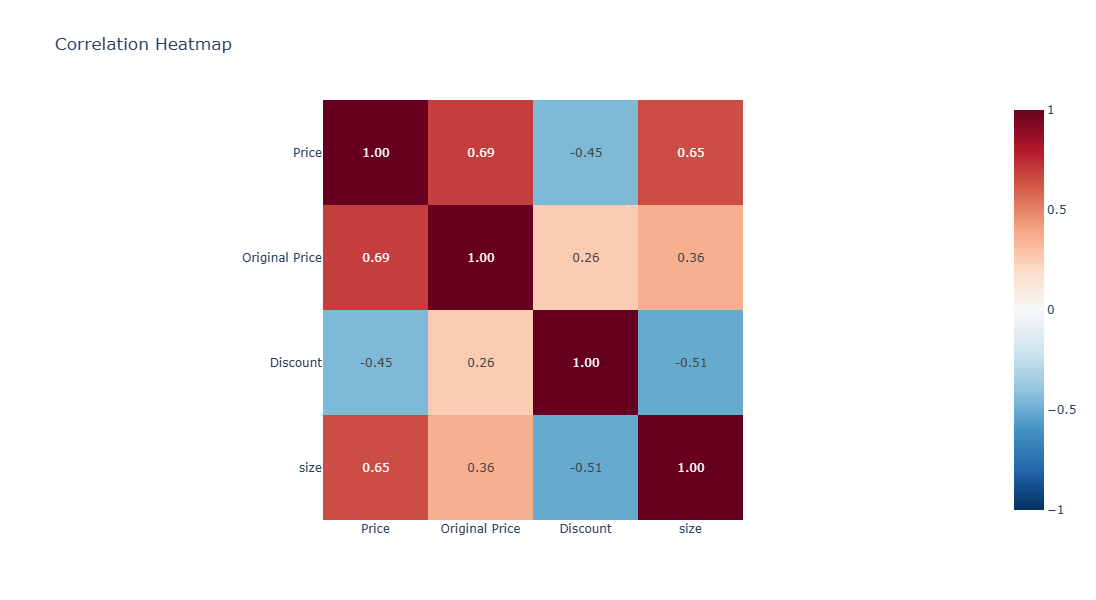

In [52]:
import plotly.express as px

# Calculate correlation matrix
corr = df[["Price", "Original Price", "Discount", "size"]].corr()

# Create heatmap
fig = px.imshow(
    corr,
    text_auto=".2f",        # Show correlation values
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlation Heatmap"
)

fig.update_layout(
    width=700,
    height=600
)

fig.show()

# Graph Output

- The heatmap shows relationships between:

- Price
- Original Price
- Discount
- Size
  # Interpretation
# Price vs Original Price

- Strong positive correlation.

- Meaning:

- When original price increases, selling price also increases.

# Price vs Discount

- Negative correlation.

- Meaning:

- Higher discounts generally reduce the final selling price.

# Price vs Size

- Weak correlation.

- Meaning:

- Shoe size does not strongly affect price.

# Relation to Problem Statement

- The heatmap identifies the important factors influencing shoe prices.

- The strongest factors are:

- Original Price

- Discount,Brand,Size has very little impact.